All dependencies

In [14]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
import tensorflow as tf

All functions

In [15]:
# ---------------------------
# Arnold Cat Map
# ---------------------------
def arnold_cat_map(img, iterations=1):
    n = img.shape[0]
    result = img.copy()

    for _ in range(iterations):
        new_img = np.zeros_like(result)
        for x in range(n):
            for y in range(n):
                x_new = (x + y) % n
                y_new = (x + 2*y) % n
                new_img[x_new, y_new] = result[x, y]
        result = new_img

    return result

# ---------------------------
# Inverse Arnold Cat Map
# ---------------------------
def inverse_arnold(img, iterations=1):
    n = img.shape[0]
    result = img.copy()

    for _ in range(iterations):
        new_img = np.zeros_like(result)
        for x in range(n):
            for y in range(n):
                x_new = (2*x - y) % n
                y_new = (-x + y) % n
                new_img[x_new, y_new] = result[x, y]
        result = new_img

    return result

# ---------------------------
# Lorenz Key Generator
# ---------------------------
def lorenz_key(values):

    os.chdir("E:\\Python n Verilog\\Lorentz 2 and Encryption\\Some pretrained models")
    model = tf.keras.models.load_model("lorentz_model.keras")

    arr = np.stack([values-10.01, values, values+10.01], axis=1)

    for _ in range(2):
        arr = model.predict(arr)

    key = np.mean(arr, axis=1)
    key = (key * 255).astype(np.uint8)

    return key

# ---------------------------
# XOR Encryption
# ---------------------------
def xor_encrypt(img, key):
    flat = img.flatten()
    encrypted = np.bitwise_xor(flat, key)
    return encrypted.reshape(img.shape) 

Main Pipeline

In [22]:
# ---------------------------
# MAIN PIPELINE
# ---------------------------

# Load image
os.chdir("E:\\Python n Verilog\\Lorentz 2 and Encryption\\Example Images")
img_name = "Capybara"
img = cv2.imread(img_name+".png")

if img is None:
    raise FileNotFoundError(f"Image {img_name}.png not found!")

# Step 1: Permutation
scrambled = arnold_cat_map(img, iterations=10)

# Step 2: Generate key
key = lorenz_key(img.flatten())

# Change to test directory
os.chdir("E:\\Python n Verilog\\Lorentz 2 and Encryption\\Test samples")

# Step 3: Diffusion
encrypted = xor_encrypt(scrambled, key)

cv2.imwrite(img_name+"_encrypted.png", encrypted)

# ---------------------------
# DECRYPTION
# ---------------------------

# Step 1: XOR again (same key)
decrypted_xor = xor_encrypt(encrypted, key)

# Step 2: Inverse Arnold
decrypted = inverse_arnold(decrypted_xor, iterations=10)

cv2.imwrite(img_name+"_decrypted.png", decrypted)

15000/15000 ━━━━━━━━━━━━━━━━━━━━ 16s 1ms/step
15000/15000 ━━━━━━━━━━━━━━━━━━━━ 15s 981us/step


True

In [23]:
print(np.array_equal(img, decrypted))
diff = np.abs(img.astype(int) - decrypted.astype(int))
print(diff.max())

True
0


Plot Matrices

RGB Entropies: 7.6405716 7.6189194 7.6116858


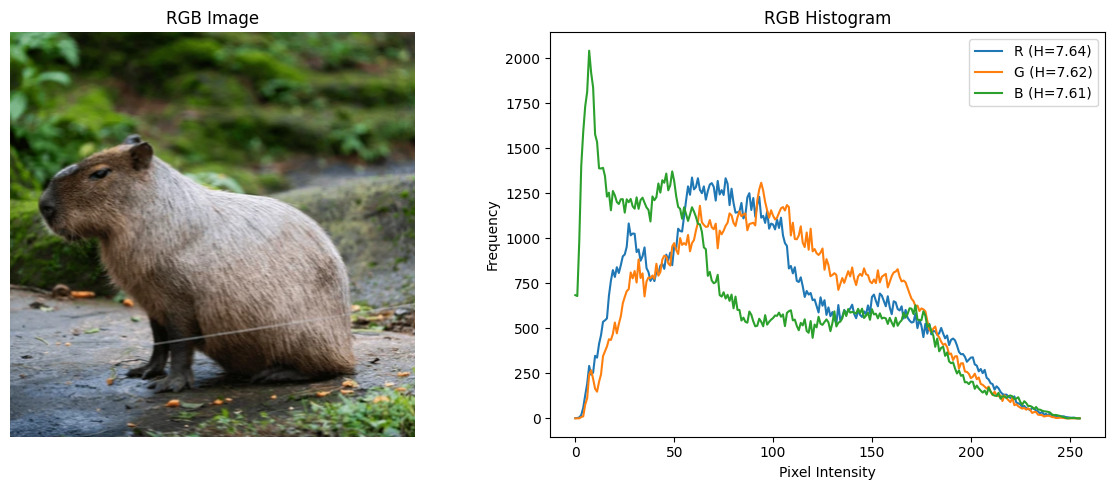

RGB Entropies: 7.9986944 7.9985247 7.997937


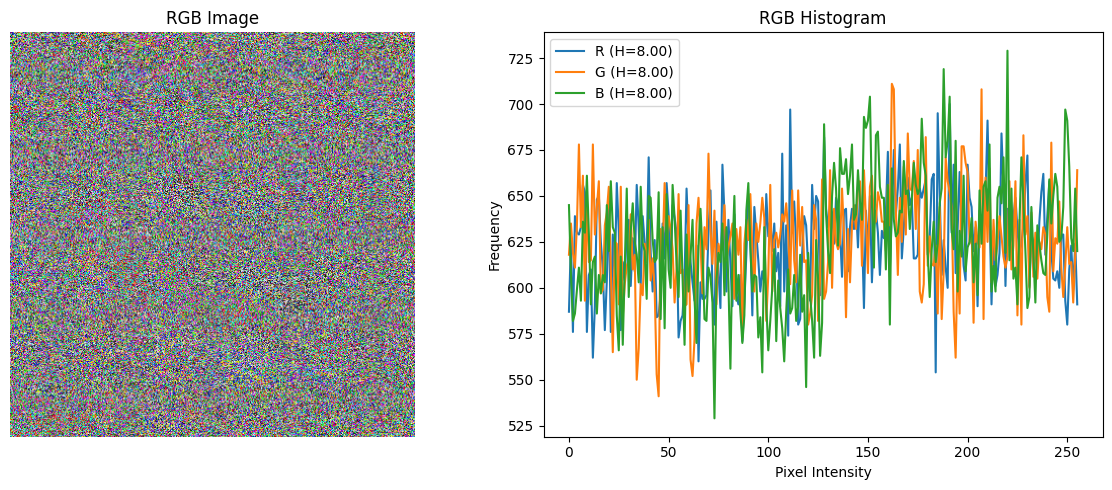

RGB Entropies: 7.6405716 7.6189194 7.6116858


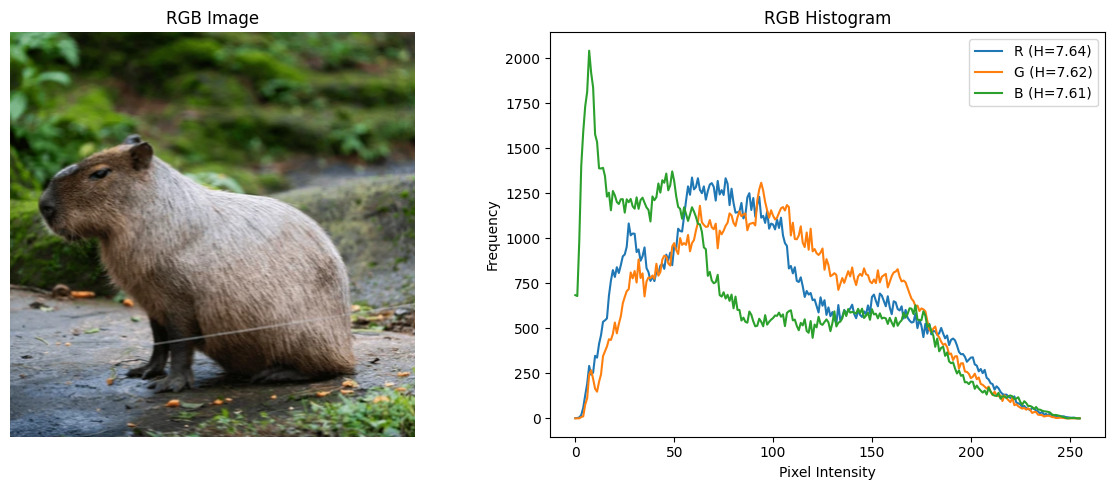

In [24]:
def compute_histogram_gray(img):
    hist = cv2.calcHist([img], [0], None, [256], [0, 256])
    return hist.flatten()


def compute_histogram_rgb(img):
    hist_r = cv2.calcHist([img], [2], None, [256], [0, 256])
    hist_g = cv2.calcHist([img], [1], None, [256], [0, 256])
    hist_b = cv2.calcHist([img], [0], None, [256], [0, 256])
    return hist_r.flatten(), hist_g.flatten(), hist_b.flatten()


def compute_entropy(hist):
    prob = hist / np.sum(hist)
    prob = prob[prob > 0]
    return -np.sum(prob * np.log2(prob))


def plot_gray(img, hist, entropy):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.title("Grayscale Image")
    plt.axis('off')

    # Histogram
    plt.subplot(1, 2, 2)
    plt.plot(hist)
    plt.title(f"Histogram (Entropy = {entropy:.4f})")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()


def plot_rgb(img, hist_r, hist_g, hist_b, entropies):
    # Convert BGR → RGB for display
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 5))

    # Image
    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title("RGB Image")
    plt.axis('off')

    # Histogram
    plt.subplot(1, 2, 2)
    plt.plot(hist_r, label=f"R (H={entropies[0]:.2f})")
    plt.plot(hist_g, label=f"G (H={entropies[1]:.2f})")
    plt.plot(hist_b, label=f"B (H={entropies[2]:.2f})")

    plt.title("RGB Histogram")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    plt.legend()

    plt.tight_layout()
    plt.show()


color_img1 = img
hist_r, hist_g, hist_b = compute_histogram_rgb(color_img1)

entropy_r = compute_entropy(hist_r)
entropy_g = compute_entropy(hist_g)
entropy_b = compute_entropy(hist_b)

print("RGB Entropies:", entropy_r, entropy_g, entropy_b)

plot_rgb(color_img1, hist_r, hist_g, hist_b,
            [entropy_r, entropy_g, entropy_b])


color_img2 = encrypted
hist_r, hist_g, hist_b = compute_histogram_rgb(color_img2)

entropy_r = compute_entropy(hist_r)
entropy_g = compute_entropy(hist_g)
entropy_b = compute_entropy(hist_b)

print("RGB Entropies:", entropy_r, entropy_g, entropy_b)

plot_rgb(color_img2, hist_r, hist_g, hist_b,
            [entropy_r, entropy_g, entropy_b])


color_img3 = decrypted
hist_r, hist_g, hist_b = compute_histogram_rgb(color_img3)

entropy_r = compute_entropy(hist_r)
entropy_g = compute_entropy(hist_g)
entropy_b = compute_entropy(hist_b)

print("RGB Entropies:", entropy_r, entropy_g, entropy_b)

plot_rgb(color_img3, hist_r, hist_g, hist_b,
            [entropy_r, entropy_g, entropy_b])